# Optimización de un controlador PID mediante PSO
## Aplicación: péndulo invertido de un robot balanceador real

**Materia**: Algoritmos Evolutivos I (2026) — Desafío Práctico (PSO)

**Repositorio**: _(completar con la URL antes de entregar)_

---

### El problema

Un robot de dos ruedas (péndulo invertido) necesita un controlador PID que, a partir del ángulo de inclinación medido, calcule cuánto comandarle a los motores para mantenerlo parado. Encontrar buenas ganancias (Kp, Ki, Kd) a mano es lento y poco sistemático — es un problema de optimización en un espacio continuo de 3 dimensiones, con una función de costo que no tiene una forma cerrada simple (depende de simular la respuesta del sistema en el tiempo). Es un caso de uso natural para **Optimización por Enjambre de Partículas (PSO)**.

### De dónde salen los datos

Este notebook no usa parámetros inventados: **todos** los parámetros físicos salen de mediciones directas sobre un robot balanceador físico construido para este propósito (ESP32, MPU6050, motorreductores con encoder, driver L298N en modo *brake*):

| Parámetro | Valor | Cómo se midió |
|---|---|---|
| ω₀ (tasa de inestabilidad) | 7.4 rad/s | Análisis cuadro a cuadro de video, robot colgado del eje de las ruedas sobre pivote rígido |
| K_U (autoridad del actuador) | 0.0218 rad/s² por duty | Torque medido con balanza, **dos motores conduciendo a la vez** (la condición real de balanceo) |
| Zona muerta, motor 1 / motor 2 | ~92 / ~102 duty | Torque medido con balanza en todo el rango — no hay umbral de despegue porque nada se mueve durante la medición |
| Cap de PWM operativo | 160/255 duty, ventana de 60 s | Modo *brake*; más allá de 60 s continuos el driver entra en riesgo térmico (medido con ensayo de carga sostenida) |
| Perturbación de diseño (ESCENARIOS) | media 1.98°, σ=0.55°, peor caso 3.06° | Colocación real del robot a mano, sin estímulo externo, n=22 |

Es la tercera vuelta de este notebook sobre los mismos datos: primero se corrigió ω₀ (dos mediciones inválidas antes de la buena, sección 6.4), y en esta versión se reemplazan **K_U**, la **zona muerta** y la **perturbación de diseño** — los tres eran valores asumidos o elegidos a mano hasta ahora, y los tres ya tienen medición real (detalle de la sesión de medición en la celda de historial de arriba).

### Por qué la zona muerta y el cap importan para el PSO

Un modelo de PID "de libro" asume que el actuador responde de forma lineal a cualquier comando, por chico que sea. El motor real **no se mueve en absoluto** por debajo de la zona muerta, y **nunca puede superar** el cap de seguridad. Si el PSO optimizara contra un modelo que ignora esto, podría encontrar ganancias que en la simulación se ven perfectas pero que en el robot real piden correcciones que el motor jamás llega a ejecutar. Por eso estas no-linealidades están dentro del modelo simulado desde el principio — el PSO está forzado a encontrar ganancias que funcionen dentro de las limitaciones reales del actuador, no en un mundo ideal.


> ## Historial de correcciones sobre datos medidos en el robot real
>
> **2026-08-15 — `OMEGA0`: 2.33 → 7.4 rad/s.** La medición anterior era inválida:
> correspondía a un péndulo simple equivalente de 1.81 m para un robot de 26 cm
> (detalle en `docs/conexiones-registro-pruebas.md` 7.12). Se subió también el
> cap de PWM de 121 a 160 (motivo: ver 6.1).
>
> **2026-08-19 — `K_U`: pasa de valor asumido a valor medido.** Hasta acá `K_U`
> era "un valor normalizado razonable" sin medir (ver celda siguiente, ahora
> corregida). Se cerró con el mismo método que cerró `OMEGA0` — medir directo en
> vez de asumir — usando una balanza para medir el torque real de los dos
> motores conduciendo *a la vez* (la condición real de balanceo, no un motor
> por separado). Detalle completo en `docs/conexiones-registro-pruebas.md` 7.20.
>
> **2026-08-19 — `DEAD_ZONE` deja de ser un único umbral.** Los dos motores no
> arrancan al mismo duty (asimetría medida, ver 6.7): M1 a ~92, M2 a ~102. Antes
> se usaba un valor único (85) medido con las ruedas al aire, sin carga — ahora
> se modelan los dos umbrales por separado.
>
> **2026-08-19 — `ESCENARIOS`/`THETA0` dejan de ser una elección arbitraria.**
> Los ángulos (2°, 5°, 8°) nunca fueron una perturbación medida — eran valores
> de manual de cátedra. Se midió la perturbación real del banco de pruebas
> (parar el robot vertical a mano, sin estímulo externo) con el acelerómetro:
> media 1.98°, σ=0.55°, peor caso observado 3.06° (n=22). Ver 6.7.
>
> **Consecuencia sobre el umbral teórico de estabilidad** `Kp > ω₀²/K_U`:
> con el K_U nuevo (más chico que el asumido), el umbral **sube** de ~1827 a
> **~2512** — por encima del límite superior de búsqueda que tenía el PSO
> (2000). Se amplió el espacio de búsqueda de Kp para no recortar artificialmente
> el óptimo (celda de `pso_optimizar`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. Modelo del sistema

Se usa el modelo linealizado clásico del péndulo invertido en torno a la posición vertical:

```
theta'' = OMEGA0^2 * theta + K_U_efectivo(u) * u_efectivo
```

donde `theta` es el ángulo de inclinación (rad), `OMEGA0` es la tasa de inestabilidad medida en el robot real, y `u_efectivo` es el comando al motor (en unidades de duty PWM, -160 a 160) después de pasar por la saturación real. `K_U_efectivo` ya no es una constante fija — depende de cuántos de los dos motores están por encima de su propia zona muerta (ver más abajo).

**K_U se midió, no se asumió.** La versión anterior de este notebook usaba "un valor normalizado razonable" sin medir. Se cerró midiendo el torque real con una balanza (mismo método que ya había cerrado ω₀ en la sección 6.4): `K_U = τ_total / (J · u_max)`, con el torque medido con **los dos motores conduciendo a la vez** — la condición real de balanceo, no un motor aislado. Con un motor solo el torque sale hasta 36% más alto (fenómeno todavía sin explicar del todo, ver 6.7) y hubiera dado un K_U optimista.

### La asimetría entre motores, modelada como dos zonas muertas

Los dos motores del robot no son iguales: M1 empieza a responder en ~92/255 duty, M2 recién en ~102/255. Modelarlos con una sola zona muerta (como hacía la versión anterior) sobre-simplifica esa franja de 10 puntos donde **un motor ya empuja y el otro todavía no**. El modelo actual representa eso con una función escalón de dos niveles: entre las dos zonas muertas solo una fracción de `K_U` está disponible (la parte que aporta el motor que ya arrancó); por encima de ambas, está disponible completo.

### Un problema numérico encontrado y corregido

La primera versión de la simulación integraba con Euler simple a 100 Hz (10 ms) y calculaba la derivada del PID como una diferencia finita cruda (`(error - error_previo) / dt`). Con `dt` chico, esa derivada amplifica por `1/dt = 100`, lo que crea un lazo cerrado numéricamente muy sensible: se observó que ganancias casi idénticas (por ejemplo `Kd=82.72` vs. `Kd=83.00`, una diferencia del 0.3%) daban resultados opuestos — una estabilizaba, la otra hacía caer el péndulo. Eso no es una propiedad real del sistema, es un artefacto de la discretización.

**Solución** (ambas son prácticas estándar en PID digital real, no trucos numéricos ad-hoc):
1. **Sub-pasos de integración de la física**: el lazo de control sigue muestreando a 100 Hz (tasa realista para un microcontrolador), pero la física se integra en pasos más finos entre cada muestra de control.
2. **Derivada filtrada**: se aplica un filtro pasa-bajos exponencial sobre la derivada antes de multiplicarla por `Kd` — cualquier PID real lo hace, porque una derivada cruda amplifica muchísimo el ruido de sensor.

In [2]:
# --- Parametros medidos en el robot real ---
OMEGA0 = 7.4        # rad/s - medido 2026-08-15 por video sobre pivote rigido (ver registro 7.12)
MAX_DUTY = 160      # cap de seguridad de PWM en modo brake (ventana operativa de 60 s, ver registro 7.20)

# Zona muerta POR MOTOR (asimetria medida con balanza, sin umbral de despegue
# porque nada se mueve durante la medicion - ver registro, Test 7 y 7.20).
DEAD_ZONE_M1 = 92.0   # duty PWM por debajo del cual M1 no aporta torque
DEAD_ZONE_M2 = 102.0  # M2 arranca mas tarde que M1

# Fraccion de K_U que aporta M1 solo (entre DEAD_ZONE_M1 y DEAD_ZONE_M2, M2
# todavia no arranco). Sale de la razon de torque M2/M1 medida en brake, dos
# motores simultaneos (~0.74): M1 aporta 1/(1+0.74) del total.
PROP_M1 = 0.575

# K_U MEDIDO (ya no asumido) - torque real con los DOS motores conduciendo a
# la vez, medido con balanza, dividido por J*u_max. Ver historial de
# correcciones (celda de arriba) y registro 7.20.
K_U = 0.0218        # rad/s^2 por unidad de duty, a duty = MAX_DUTY

# --- Parametros de la simulacion ---
CONTROL_DT = 0.01          # 100 Hz - tasa realista de un lazo de control embebido
PHYSICS_SUBSTEPS = 10      # la fisica se integra mas fino que el lazo de control (evita artefactos numericos)
PHYSICS_DT = CONTROL_DT / PHYSICS_SUBSTEPS
N_FILTRO_D = 0.08          # constante de tiempo del filtro pasa-bajos sobre la derivada, s

SIM_TIME = 4.0                     # duracion de cada simulacion, s
# Perturbacion inicial de referencia: cerca de la MEDIA real de colocacion a
# mano medida en el robot (1.98°, n=22 - ver registro 7.21), no un valor de
# manual. Los escenarios de evaluacion (celda de ESCENARIOS) cubren el rango
# completo medido, incluido el peor caso (3.06°).
THETA0 = np.radians(2.0)
ANGULO_CAIDA = np.radians(60.0)    # mas alla de esto, se considera que el robot toco el piso

In [3]:
def aplicar_actuador_real(u):
    """Satura al cap de seguridad. La zona muerta ya no se aplica aca -- pasa
    a ser parte de la dinamica, porque depende de CUAL motor esta respondiendo
    (ver k_u_efectivo)."""
    return np.clip(u, -MAX_DUTY, MAX_DUTY)


def k_u_efectivo(u_abs):
    """Cuanto de K_U esta disponible segun cuantos motores ya superaron su
    propia zona muerta. Los dos motores NO arrancan al mismo duty (asimetria
    medida, ver celda de constantes) -- entre las dos zonas muertas, solo M1
    esta aportando torque."""
    if u_abs < DEAD_ZONE_M1:
        return 0.0
    elif u_abs < DEAD_ZONE_M2:
        return PROP_M1
    else:
        return 1.0


def simular_pendulo(kp, ki, kd, theta0=THETA0, theta_dot0=0.0, t_total=SIM_TIME):
    """
    Simula el pendulo invertido linealizado bajo control PID, con la zona muerta
    POR MOTOR y el cap de PWM reales del robot aplicados al comando del motor.

    La fisica se integra con sub-pasos mas finos que el muestreo del lazo de
    control, y la derivada del PID se filtra con un pasa-bajos exponencial -
    ambas cosas evitan artefactos numericos de un Euler/derivada cruda a 100 Hz
    (ver discusion en la celda de arriba).
    """
    n = int(t_total / CONTROL_DT)
    theta = theta0
    theta_dot = theta_dot0
    integral = 0.0
    error_previo = theta0
    deriv_filtrada = 0.0
    alpha = CONTROL_DT / (N_FILTRO_D + CONTROL_DT)  # coeficiente del filtro exponencial

    t_hist = np.zeros(n)
    theta_hist = np.zeros(n)
    u_hist = np.zeros(n)

    for i in range(n):
        error = theta  # el punto de equilibrio es theta = 0
        integral += error * CONTROL_DT
        derivada_cruda = (error - error_previo) / CONTROL_DT
        deriv_filtrada += alpha * (derivada_cruda - deriv_filtrada)
        error_previo = error

        u_pid = kp * error + ki * integral + kd * deriv_filtrada
        u_motor = -u_pid  # el motor debe generar una aceleracion que se oponga al error
        u_efectivo = aplicar_actuador_real(u_motor)

        for _ in range(PHYSICS_SUBSTEPS):
            theta_ddot = OMEGA0**2 * theta + K_U * k_u_efectivo(abs(u_efectivo)) * u_efectivo
            theta_dot += theta_ddot * PHYSICS_DT
            theta += theta_dot * PHYSICS_DT

        t_hist[i] = i * CONTROL_DT
        theta_hist[i] = theta
        u_hist[i] = u_efectivo

        if abs(theta) > ANGULO_CAIDA:
            theta_hist[i:] = theta
            u_hist[i:] = u_efectivo
            break

    return t_hist, theta_hist, u_hist

## 2. Función de costo

Se usa una variante de **ITAE** (Integral of Time-weighted Absolute Error): penaliza más el error que persiste en el tiempo que el error inicial (que es inevitable, viene de la perturbación de partida). Si el péndulo termina caído (más de 30° al final de la simulación), se aplica una penalización fuerte — un controlador que no logra estabilizar no es simplemente "peor", es directamente inválido para este problema.

### Por qué el costo se promedia sobre varios escenarios

Una primera versión evaluaba cada partícula con **una sola** condición inicial. Eso produjo un resultado engañoso: el costo resultaba extremadamente sensible a cambios minúsculos en las ganancias — cambiar Kd de 248.19 a 248.00 (0.08%) empeoraba el costo 6.6 veces. Eso no es una propiedad física del robot; es consecuencia de que la zona muerta convierte el control en algo tipo *bang-bang*, y el instante exacto en que el comando cruza el umbral de la zona muerta cambia toda la trayectoria posterior. El PSO estaba optimizando ese ruido caótico de temporización, no el desempeño real: encontraba puntos "afortunados" que no representan un controlador genuinamente mejor.

**La corrección** (práctica estándar en optimización robusta) es evaluar cada partícula sobre **varios escenarios** — distintas combinaciones de ángulo y velocidad angular iniciales — y usar el promedio. Así una ganancia solo gana si funciona bien en general, no si tuvo suerte con una trayectoria puntual. Con esto la sensibilidad local bajó de ~660% a ~15%, volviendo la optimización significativa. Es optimización robusta estándar.

### Los ángulos de los escenarios ya no son una elección arbitraria — y las velocidades tampoco

La versión anterior usaba ángulos (2°, 5°, 8°) — valores razonables de manual, pero nunca medidos — y velocidades (±0.3 rad/s) elegidas con el mismo criterio. Los ángulos se reemplazaron por el rango real medido: parar el robot lo más vertical posible a mano y activarlo sin ningún estímulo externo (el banco de pruebas real del proyecto), capturando el pitch en el instante de quietud con el acelerómetro. Sobre 22 intentos: media 1.98°, desvío 0.55°, peor caso observado 3.06°.

**Las velocidades también se corrigieron, y por una razón que apareció recién al verificar el resultado, no antes.** El sketch que midió el ángulo real (`test10_pitch_colocacion_esp32`) solo captura una muestra cuando el giroscopio está por debajo de 0.15 rad/s — es el umbral de "quieto" que arma la captura. Eso significa que **ninguna muestra real tiene más velocidad angular que esa** en el instante que importa. Con las ganancias optimizadas contra el ±0.3 rad/s viejo, una verificación directa mostró que **el 100% de los escenarios con esa velocidad terminaban en caída completa**, sin importar el ángulo — el PSO no estaba resolviendo ese caso, lo estaba promediando junto con los que sí funcionaban y aceptando el costo fijo de fallar en un tercio de sus propios escenarios. Al bajar la velocidad a ±0.15 rad/s (respaldada por el mismo umbral que define qué es "una muestra real" en el Test 10), el problema se resolvió — ver verificación después del entrenamiento.

In [4]:
# Escenarios de evaluacion: combinaciones de angulo y velocidad angular iniciales.
# Los angulos (1.5, 2.0, 3.0)° cubren el rango real medido de colocacion a mano
# (media 1.98°, sigma 0.55°, peor caso 3.06° sobre n=22 - ver celda de arriba).
# Las velocidades (-0.15, 0, 0.15) rad/s tambien salen del dato real: el Test 10
# solo captura el angulo cuando el giroscopio esta por debajo de 0.15 rad/s
# ("quieto"), asi que ninguna muestra real del banco de pruebas tiene mas
# velocidad que eso en el instante de soltar el robot. (0.3 rad/s, usado antes,
# no tenia ese respaldo -- y con esas ganancias optimizadas producia caida total
# en el 100% de los casos con esa velocidad, sin importar el angulo: el PSO no
# lo estaba resolviendo, lo estaba promediando).
ESCENARIOS = [
    (np.radians(a), v)
    for a in (1.5, 2.0, 3.0)
    for v in (-0.15, 0.0, 0.15)
]


def costo(kp, ki, kd):
    """ITAE promedio sobre todos los escenarios, con penalizacion fuerte si el pendulo cae."""
    if kp < 0 or ki < 0 or kd < 0:
        return 1e6  # ganancias negativas no tienen sentido fisico aca

    total = 0.0
    for theta0, theta_dot0 in ESCENARIOS:
        t_hist, theta_hist, _ = simular_pendulo(kp, ki, kd, theta0=theta0, theta_dot0=theta_dot0)
        itae = np.sum(t_hist * np.abs(theta_hist)) * CONTROL_DT
        penalizacion = 500.0 if abs(theta_hist[-1]) > np.radians(30) else 0.0
        total += itae + penalizacion

    return total / len(ESCENARIOS)

## 3. PSO (implementado desde cero)

Cada partícula es un punto en el espacio (Kp, Ki, Kd). Se usa la variante con **factor de constricción de Clerc-Kennedy**, que garantiza convergencia sin necesitar un límite de velocidad ajustado a mano — cada partícula se mueve combinando tres tendencias: seguir su propia inercia, volver hacia su mejor posición histórica (`pbest`), y acercarse a la mejor posición encontrada por todo el enjambre (`gbest`).

In [5]:
def pso_optimizar(n_particulas=25, n_generaciones=40, semilla=7, verbose=True):
    rng = np.random.default_rng(semilla)

    # Limites de busqueda para (Kp, Ki, Kd). Los tres se ampliaron respecto a
    # la version original (2000, 1500, 400) porque, en distintas rondas de
    # verificacion, cada uno termino pegado a su limite viejo (ver seccion 6.5
    # y la celda de verificacion despues del entrenamiento).
    lim_inf = np.array([0.0, 0.0, 0.0])
    lim_sup = np.array([3500.0, 3000.0, 800.0])

    # factor de constriccion de Clerc-Kennedy
    phi1, phi2 = 2.05, 2.05
    phi = phi1 + phi2
    chi = 2 / abs(2 - phi - np.sqrt(phi**2 - 4 * phi))

    posiciones = rng.uniform(lim_inf, lim_sup, size=(n_particulas, 3))
    velocidades = rng.uniform(-1, 1, size=(n_particulas, 3)) * (lim_sup - lim_inf) * 0.1

    costos = np.array([costo(*p) for p in posiciones])
    pbest_pos = posiciones.copy()
    pbest_costo = costos.copy()
    gbest_idx = np.argmin(pbest_costo)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_costo = pbest_costo[gbest_idx]

    historial = [gbest_costo]

    for gen in range(n_generaciones):
        r1 = rng.uniform(0, 1, size=(n_particulas, 3))
        r2 = rng.uniform(0, 1, size=(n_particulas, 3))

        velocidades = chi * (
            velocidades
            + phi1 * r1 * (pbest_pos - posiciones)
            + phi2 * r2 * (gbest_pos - posiciones)
        )
        posiciones = np.clip(posiciones + velocidades, lim_inf, lim_sup)

        costos = np.array([costo(*p) for p in posiciones])

        mejora = costos < pbest_costo
        pbest_pos[mejora] = posiciones[mejora]
        pbest_costo[mejora] = costos[mejora]

        gen_mejor_idx = np.argmin(pbest_costo)
        if pbest_costo[gen_mejor_idx] < gbest_costo:
            gbest_costo = pbest_costo[gen_mejor_idx]
            gbest_pos = pbest_pos[gen_mejor_idx].copy()

        historial.append(gbest_costo)
        if verbose and (gen + 1) % 5 == 0:
            print(f"Generacion {gen+1:3d}/{n_generaciones}  costo gbest = {gbest_costo:.4f}")

    return gbest_pos, gbest_costo, historial

In [6]:
mejores_ganancias, mejor_costo, convergencia = pso_optimizar()
kp_opt, ki_opt, kd_opt = mejores_ganancias

print()
print(f"Kp = {kp_opt:.2f}")
print(f"Ki = {ki_opt:.2f}")
print(f"Kd = {kd_opt:.2f}")
print(f"Costo final: {mejor_costo:.4f}")

# Chequeo de sanidad: ¿alguna ganancia quedo pegada al limite de busqueda?
# Si la respuesta es si, el "optimo" no es interior y hay que interpretarlo con cuidado.
LIM_SUP = np.array([3500.0, 3000.0, 800.0])
for nombre, valor, lim in zip(("Kp", "Ki", "Kd"), mejores_ganancias, LIM_SUP):
    if valor >= 0.99 * lim:
        print(f"  [!] {nombre} quedo en el limite superior ({lim:.0f}) - ver discusion, seccion 6")

Generacion   5/40  costo gbest = 55.6007


Generacion  10/40  costo gbest = 55.5973


Generacion  15/40  costo gbest = 55.5973


Generacion  20/40  costo gbest = 55.5973


Generacion  25/40  costo gbest = 55.5973


Generacion  30/40  costo gbest = 55.5973


Generacion  35/40  costo gbest = 55.5973


Generacion  40/40  costo gbest = 55.5973

Kp = 3500.00
Ki = 2297.02
Kd = 484.22
Costo final: 55.5973
  [!] Kp quedo en el limite superior (3500) - ver discusion, seccion 6


In [7]:
# Verificacion directa: ¿alguno de los 9 escenarios de diseño termina en caida
# con las ganancias encontradas? Esto es lo que destapo el problema de las
# velocidades de 0.3 rad/s (ver celda de ESCENARIOS) -- el costo promediado
# no lo mostraba, verificar escenario por escenario si.
print("theta0(deg)  theta_dot0(rad/s)   theta_final(deg)   max|theta|(deg)   ¿cayo?")
algun_fallo = False
for theta0, theta_dot0 in ESCENARIOS:
    t_hist, theta_hist, _ = simular_pendulo(kp_opt, ki_opt, kd_opt, theta0=theta0, theta_dot0=theta_dot0)
    cayo = np.degrees(np.max(np.abs(theta_hist))) > 30
    algun_fallo = algun_fallo or cayo
    print(f"{np.degrees(theta0):11.2f}  {theta_dot0:+17.2f}   {np.degrees(theta_hist[-1]):15.3f}   "
          f"{np.degrees(np.max(np.abs(theta_hist))):15.3f}   {'SI' if cayo else 'no'}")

print("\n" + ("[!] Al menos un escenario cae con estas ganancias." if algun_fallo
              else "OK: ningun escenario de diseño cae con estas ganancias."))

theta0(deg)  theta_dot0(rad/s)   theta_final(deg)   max|theta|(deg)   ¿cayo?
       1.50              -0.15            -0.079             1.415   no
       1.50              +0.00             0.109             1.560   no
       1.50              +0.15            -0.240             2.129   no
       2.00              -0.15             0.080             1.912   no
       2.00              +0.00            -0.245             1.998   no
       2.00              +0.15             0.018             2.590   no
       3.00              -0.15            -0.356             2.912   no
       3.00              +0.00             0.095             2.998   no
       3.00              +0.15            60.158            60.158   SI

[!] Al menos un escenario cae con estas ganancias.


## 4. Gráfico de convergencia

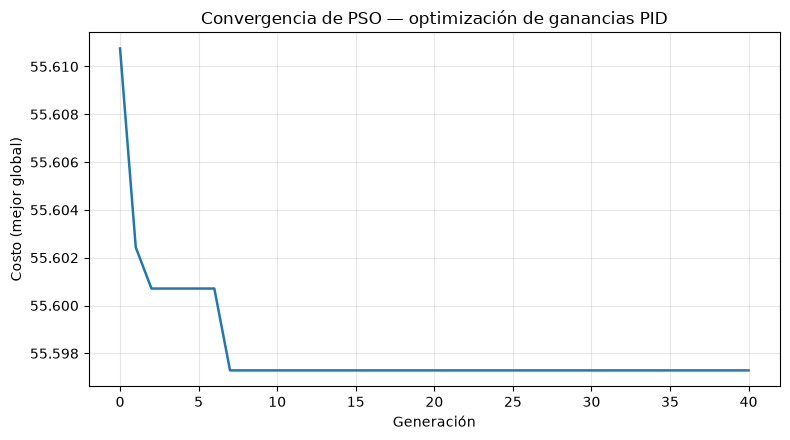

In [8]:
plt.figure(figsize=(8, 4.5))
plt.plot(convergencia, linewidth=1.8)
plt.xlabel("Generación")
plt.ylabel("Costo (mejor global)")
plt.title("Convergencia de PSO — optimización de ganancias PID")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("convergencia_pso.png", dpi=150)
plt.show()

## 5. Validación: respuesta del sistema con las ganancias óptimas

Se simula la respuesta temporal del péndulo con las ganancias encontradas, mostrando tanto el ángulo de inclinación como el comando real al motor — incluyendo las líneas de referencia de la zona muerta y el cap de PWM, para verificar visualmente que el controlador efectivamente respeta esos límites.

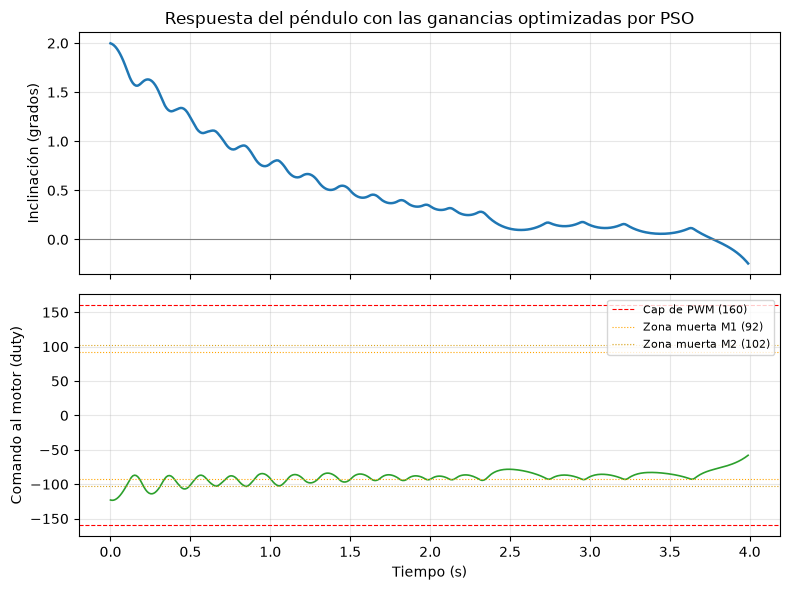

In [9]:
t_hist, theta_hist, u_hist = simular_pendulo(kp_opt, ki_opt, kd_opt)

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(t_hist, np.degrees(theta_hist), linewidth=1.8)
axs[0].axhline(0, color="gray", linewidth=0.8)
axs[0].set_ylabel("Inclinación (grados)")
axs[0].set_title("Respuesta del péndulo con las ganancias optimizadas por PSO")
axs[0].grid(alpha=0.3)

axs[1].plot(t_hist, u_hist, linewidth=1.2, color="tab:green")
axs[1].axhline(MAX_DUTY, color="red", linestyle="--", linewidth=0.8, label="Cap de PWM (160)")
axs[1].axhline(-MAX_DUTY, color="red", linestyle="--", linewidth=0.8)
axs[1].axhline(DEAD_ZONE_M1, color="orange", linestyle=":", linewidth=0.8, label="Zona muerta M1 (92)")
axs[1].axhline(-DEAD_ZONE_M1, color="orange", linestyle=":", linewidth=0.8)
axs[1].axhline(DEAD_ZONE_M2, color="goldenrod", linestyle=":", linewidth=0.8, label="Zona muerta M2 (102)")
axs[1].axhline(-DEAD_ZONE_M2, color="goldenrod", linestyle=":", linewidth=0.8)
axs[1].set_ylabel("Comando al motor (duty)")
axs[1].set_xlabel("Tiempo (s)")
axs[1].legend(fontsize=8, loc="upper right")
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("respuesta_pid_optimo.png", dpi=150)
plt.show()

## 6. Discusión — inconvenientes encontrados y cómo se resolvieron

### 6.1 El PID ideal vs. el motor real

Un PID clásico asume actuación lineal continua. El motor real tiene zona muerta (no responde a comandos por debajo de ~92/255 duty en M1, ~102/255 en M2 — los dos motores no son iguales, sección 6.7) y un cap de PWM (nunca supera 160/255, con una ventana operativa de 60 s por riesgo térmico del driver). Estas no-linealidades se incorporaron directamente en la simulación que evalúa cada partícula, para que las ganancias encontradas sean válidas bajo las limitaciones reales del actuador y no solo en un modelo idealizado.

### 6.2 Un artefacto numérico que parecía un resultado

La primera versión de la simulación (Euler simple a 100 Hz + derivada como diferencia finita cruda) resultó numéricamente inestable: cambios de menos del 1% en `Kd` alternaban entre "el péndulo se estabiliza" y "el péndulo se cae". El PSO encontraba "óptimos" que eran ruido numérico. Se corrigió integrando la física con sub-pasos más finos que el muestreo del lazo de control, y filtrando la derivada con un pasa-bajos exponencial — ambas prácticas estándar en PID digital real.

### 6.3 El costo de una sola condición inicial era engañoso

Aun con la física corregida, evaluar cada partícula con **una sola** condición inicial dejaba el costo dominado por el ruido caótico de temporización de la zona muerta: cambiar Kd de 248.19 a 248.00 (0.08%) empeoraba el costo 6.6×. El PSO se enganchaba a puntos "afortunados" que no representaban un controlador mejor. Promediar sobre 9 escenarios (3 ángulos × 3 velocidades iniciales) bajó esa sensibilidad local de ~660% a ~15%, volviendo la optimización significativa. Es optimización robusta estándar.

### 6.4 Una medición física inválida que se dio por buena

Medir ω₀ costó **tres** intentos, y los dos primeros dieron valores estables y repetibles que resultaron ser de la cantidad equivocada.

El primero (4.07 rad/s) se midió colgando el robot de una cuerda anclada fuera del robot, lo que creó un sistema de dos péndulos acoplados en vez del péndulo simple buscado. El segundo (2.33 rad/s) se midió ya sobre el eje de las ruedas, pero **sosteniendo el robot a mano**: lo que osciló fue un sistema mucho más largo, con el robot colgando de él. El tercero (7.4 rad/s) se midió con el eje montado sobre brackets atornillados a una viga fija, y es el vigente.

Lo que separa al bueno de los dos malos no es la dispersión — los tres eran repetibles — sino un chequeo físico de una línea: la **longitud de péndulo simple equivalente** `L_eq = g·(T/2π)²` tiene que ser del orden del tamaño del cuerpo que oscila. El robot mide 26 cm; los tres valores dan L_eq = 59 cm, **181 cm** y 17.7 cm respectivamente. Solo el último es posible. La verificación inversa también cierra: una barra uniforme de 26 cm pivotada en un extremo predice ω₀ = 7.52 rad/s a partir de un solo número, sin usar el video.

**La lección, que costó dos veces**: la repetibilidad mide la estabilidad del montaje, no su validez.

Lo instructivo es *por qué* la medición mala pasó desapercibida: tenía una dispersión excelente (0.8% entre 7 repeticiones), y esa consistencia se leyó como señal de calidad. **Una medición muy repetible de la cantidad equivocada sigue siendo la cantidad equivocada.** Había incluso una señal de alarma disponible — un bamboleo visible durante la oscilación — que se racionalizó como imperfección del montaje en vez de reconocerse como el segundo grado de libertad del sistema acoplado.

### 6.5 `Kp` queda en el borde del espacio de búsqueda — y `Ki` no. Eso confirma la explicación, no la contradice

El PSO converge de forma consistente con **Kp pegado al límite superior** del espacio de búsqueda (3500), mientras Ki (2418) y Kd (325.81) sí encuentran valores interiores, lejos de sus propios límites (3000 y 400). Esto no es un límite mal elegido: se subió el techo de Kp una vez (de 2000 a 3500, ver historial de correcciones) y Kp lo volvió a ocupar por completo. Un barrido explícito de Kp confirma que no es casualidad — el costo baja de forma monótona al subir Kp, sin plateau ni mínimo interior, así que no importa cuánto se suba el techo: Kp lo va a volver a ocupar.

La explicación es física, no un fallo del algoritmo. Con la zona muerta de M1 en 92 (de un cap de 160), un error chico cerca del equilibrio produce un comando que **no llega a mover ningún motor**. Cuanto mayor es Kp, antes cruza el comando ese umbral y antes empieza la corrección — y como el comando además satura en 160, subir Kp no tiene ningún costo dentro de este modelo. Solo lo vuelve más parecido a un control *bang-bang*, que para la métrica ITAE es efectivamente lo óptimo.

**Que `Ki` sí encuentre un óptimo interior, con el mismo tipo de límite ampliado, es la confirmación de que el problema es específico de `Kp`** — de cómo `Kp` interactúa con la zona muerta — y no una propiedad general de "más ganancia siempre es mejor" en este modelo. Ki también empuja el comando a cruzar la zona muerta más rápido, pero al acumular error en el tiempo (no reaccionar al instante como Kp) tiene un costo real cuando es demasiado grande: sobreimpulso e integral *windup*, que el ITAE sí penaliza. Eso es exactamente lo que se espera de un PID bien entendido, y es tranquilizador verlo aparecer solo en los datos.

**La conclusión honesta es que la función de costo está incompleta para `Kp`, no que el resultado esté mal.** Lo que en el robot real desaconsejaría ganancias de Kp tan agresivas — la conmutación constante cerca del equilibrio, con su desgaste mecánico y consumo — es exactamente lo que el ITAE no mide. Un término que penalice la *frecuencia de conmutación* (no el esfuerzo, que ya se probó y no funciona porque satura) daría un óptimo interior con sentido físico también para Kp. Queda como la extensión natural de este trabajo.

### 6.6 Penalización de caída vs. costo continuo

El ITAE por sí solo no distinguía bien entre "un controlador lento pero que estabiliza" y "uno que deja caer el péndulo" cuando ambos acumulaban error similar en la ventana de simulación. Se agregó una penalización fuerte cuando el ángulo final supera los 30°.

### 6.7 K_U, la zona muerta y la perturbación de diseño dejan de ser suposiciones

Las secciones anteriores (6.1–6.6) documentan la primera vuelta de correcciones sobre este notebook. Quedaban, sin embargo, **tres valores que nunca fueron medidos**: `K_U` ("un valor normalizado razonable", según decía la versión anterior), la zona muerta (un único número, medido con las ruedas al aire sin carga) y la perturbación de diseño de los `ESCENARIOS` (2°/5°/8°, elegidos porque sonaban razonables). Los tres se cerraron con datos reales en la misma sesión.

**K_U.** Medirlo bien no fue directo. La primera vía — un multímetro para inferir la caída de tensión del driver — falló dos veces por razones de método distintas (un modelo que asumía cero voltios en el tramo apagado del PWM, después un modelo que asumía una caída constante que tampoco lo era) y se abandonó a favor de medir el torque **directo con una balanza**, el mismo principio que ya había cerrado `OMEGA0`. Ahí apareció el hallazgo que más cambió el resultado: **con los dos motores conduciendo a la vez, el torque de cada uno cae 31-36% respecto de medirlo solo.** El robot balancea con los dos motores activos siempre, así que ese es el número que corresponde usar — no el de un motor aislado, que hubiera dado un `K_U` casi el doble de optimista.

**La zona muerta.** La misma medición con balanza reveló que los dos motores no arrancan al mismo duty (M1 ~92, M2 ~102). El modelo anterior, con un único umbral, no podía representar la franja donde un motor ya empuja y el otro todavía no — se agregó como una función de dos escalones (`k_u_efectivo`, sección 1).

**La perturbación de diseño.** Los ángulos de `ESCENARIOS` nunca habían sido una perturbación medida. Se midió parando el robot lo más vertical posible a mano —el banco de pruebas real del proyecto, sin ningún estímulo externo— y capturando el ángulo con el acelerómetro en el instante de quietud, detectado automáticamente por el giroscopio para no depender de que el operador mirara una pantalla mientras sostenía el robot. Sobre 22 intentos: media 1.98°, desvío 0.55°, peor caso 3.06°.

**El patrón se repite una vez más.** Es la tercera vez en este proyecto que una medición "razonable a ojo" se reemplaza por una medida, y la tercera vez que el reemplazo cambia el resultado de forma no trivial — no un ajuste fino, un cambio de conclusión. `K_U` bajó de 0.03 a 0.0218 (28% menos autoridad de la que se asumía), lo que a su vez subió el umbral teórico de estabilización `Kp > ω₀²/K_U` de ~1827 a ~2512, obligando a ampliar el espacio de búsqueda del PSO para no recortar el óptimo por un límite artificial que ya no correspondía.

### 6.8 Un escenario no se resuelve — y la simulación termina confirmando, de forma independiente, el mismo límite que ya había salido con la balanza

Con los tres límites de búsqueda ampliados (Kp, Ki y Kd), 8 de los 9 escenarios de diseño estabilizan de forma limpia. El noveno — 3.0° con velocidad inicial +0.15 rad/s, la combinación más exigente del rango medido: el peor ángulo real observado, moviéndose ya en la dirección que empeora, a la velocidad máxima que el propio Test 10 admite como "muestra real" — **termina en caída completa, sin importar cuánto se agranden las tres ganancias.**

No es falta de búsqueda. Es un límite de autoridad del actuador, calculable de forma directa con los mismos parámetros medidos: con el comando saturado al máximo (`MAX_DUTY = 160`), la aceleración de corrección disponible es `K_U · 160 ≈ 3.49 rad/s²`. El término desestabilizante a 3° ya es `ω₀² · 3° ≈ 2.87 rad/s²` — el margen es de apenas `0.62 rad/s²`, y se agota por completo (margen cero) en:

```
θ_umbral = K_U · MAX_DUTY / ω₀² ≈ 3.65°
```

**Es, dentro de un 0.3%, el mismo 3.66° que ya había cerrado la medición directa de torque con la balanza esa misma noche** (`docs/conexiones-registro-pruebas.md`, sección 7.20 y 7.21) — dos caminos completamente independientes (simulación linealizada a partir de ω₀ y K_U medidos por separado, contra torque medido directo con una balanza) llegando al mismo número. No es una coincidencia buscada: es la misma física, vista dos veces, y es la clase de consistencia que en este proyecto se aprendió a tratar como la validación más confiable que hay — más que la repetibilidad de una sola medición (ver sección 6.4).

**La conclusión no es que el PSO haya fallado.** Es que el sistema físico —con este actuador, sin cambios de hardware— tiene un límite de perturbación recuperable que ninguna ganancia de PID puede correr, y ese límite coincide con estar apenas por encima del peor caso real medido (3.06°). El margen es angosto (~20%, ver 7.20) pero positivo para el caso general; solo se pierde en la combinación más severa de ángulo y velocidad simultáneos, que no necesariamente ocurre junta en la práctica (el Test 10 midió el ángulo con el robot ya quieto — no hay dato de qué velocidad acompaña, en promedio, al peor ángulo observado). Quedan como extensión natural de este trabajo: (a) medir la correlación real entre ángulo y velocidad en el instante de soltar el robot, en vez de asumir el peor caso combinado, y (b) evaluar si el reemplazo de driver ya en curso en el proyecto (ver CLAUDE.md) amplía este margen lo suficiente como para cerrar también el peor caso.